In [8]:
# Importing modules and packages

import pandas as pd
from matplotlib import pyplot
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.compose import make_column_transformer,make_column_selector
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor


In [9]:
# Importing the data
data=pd.read_csv(r'C:\Users\Vineet\housing.csv')
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [10]:
# Exploring the data (It is found that the data has null values and one feature has string values)
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


<Axes: xlabel='longitude', ylabel='latitude'>

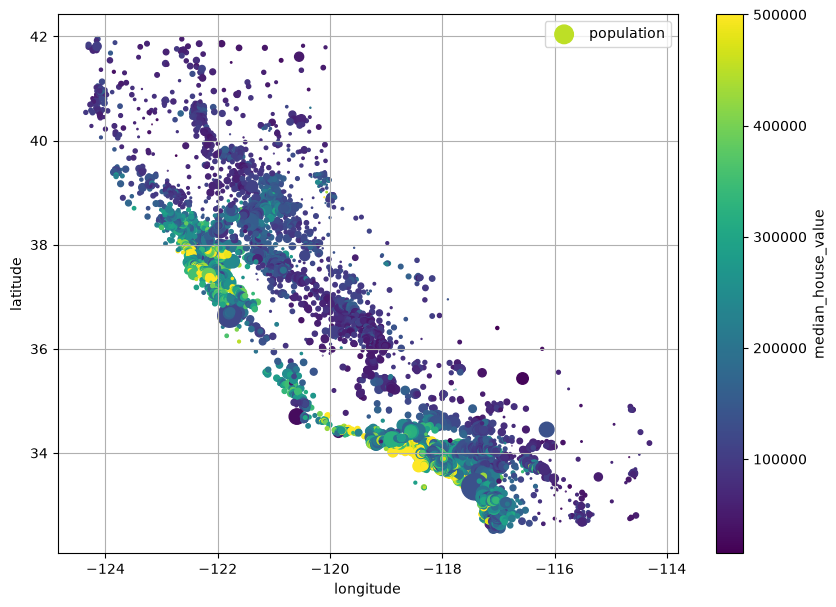

In [11]:
# Visualize the data  (This grpah shows that the housing prices are related to the
# location (e.g., close to the ocean) and to the population density )


data.plot(kind='scatter',x='longitude',y='latitude',grid=True,label='population',s=data['population']/100,
          c='median_house_value',cmap='viridis',colorbar=True,legend=True,figsize=(10,7))

In [12]:
# Finding out the strongest features(median_income turns out to be the strongest feature)

data.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [13]:
# Splitting the dataset
data_train,data_test=train_test_split(data,random_state=42,test_size=0.3)

In [14]:
#Feature Engineering
class FeatureEngineering(BaseEstimator,TransformerMixin):
    def fit(self,X,y=None):
        return self
    def transform(self,data):
        data=data.copy()
        data['rooms_per_households']=data['total_rooms']/data['households']
        data['bedrooms_room_ratio']=data['total_bedrooms']/data['total_rooms']
        data['population_per_households']=data['population']/data['households']
        return data        


In [15]:
# Preprocessing


numerical_pipeline =  make_pipeline(SimpleImputer(strategy='median')  ,  StandardScaler())

categorical_pipeline =  make_pipeline(SimpleImputer(strategy='most_frequent')  ,  OneHotEncoder())

preprocessing =  make_column_transformer((numerical_pipeline,make_column_selector(dtype_include=np.number))  ,  (categorical_pipeline,make_column_selector(dtype_include=object)))


In [16]:
# Training the model


X_train,y_train=data_train.drop(columns=['median_house_value']),data_train['median_house_value']



models = [
    LinearRegression(),
    DecisionTreeRegressor(random_state=42),
    RandomForestRegressor(random_state=42),
    XGBRegressor(random_state=42)
]

results = []

for model in models:

    pipeline = make_pipeline(
        FeatureEngineering(),
        preprocessing,
        model
    )

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    rmse = -scores.mean()

    results.append([
        model,
        rmse
    ])

df = pd.DataFrame(
    results,
    columns=['Model', 'CV_RMSE']
)

df

,Model,CV_RMSE
0,LinearRegression(),68276.932773
1,DecisionTreeRegressor(random_state=42),70835.438924
2,RandomForestRegressor(random_state=42),51041.821186
3,"XGBRegressor(base_score=None, booster=None, ca...",48128.463236
